# Single-Layer DNN Rerun

Minimal notebook to rerun only the single-layer DNN models with ROCm-backed TensorFlow and regenerate the main plots.

In [1]:
import os, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras import Sequential, optimizers
from keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('./results/Single_DNN_Layers', exist_ok=True)
output_dir_path = './results/Single_DNN_Layers/'

# Force CPU execution.
tf.config.set_visible_devices([], 'GPU')

I0000 00:00:1773848690.921214  288812 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773848690.922026  288812 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773848690.969197  288812 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773848692.266468  288812 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
df = pd.read_csv('Housing.csv').dropna()
df = df.replace({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})

data_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df), columns=df.columns)
X_data = data_scaled[['area', 'bathrooms', 'stories', 'airconditioning']]
y_data = data_scaled['price']
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.30, random_state=20)

print('Training Sets:', X_train.shape, y_train.shape)
print('Test Sets:', X_test.shape, y_test.shape)

Training Sets: (381, 4) (381,)
Test Sets: (164, 4) (164,)


In [3]:
def scores(y_true, y_pred):
    return {
        'rmse': math.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mean_absolute_percentage_error(y_true, y_pred),
        'R2_score': r2_score(y_true, y_pred),
        'R': np.corrcoef(y_true, y_pred)[0, 1],
    }

def build_model(layers, input_features=4, output_dim=1, optimizer='Adagrad', learning_rate=0.001, verbose=1):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_features, activation='relu'))
    model.add(Dropout(0.10))
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.10))
    model.add(Dense(output_dim, activation='linear'))
    opt = {'Adam': optimizers.Adam, 'Adagrad': optimizers.Adagrad, 'Nadam': optimizers.Nadam, 'Adadelta': optimizers.Adadelta, 'RMSprop': optimizers.RMSprop}[optimizer](learning_rate=learning_rate)
    model.compile(loss='mean_squared_error', optimizer=opt)
    if verbose:
        print(model.summary())
    return model

def run_one_model(layers, hyper, epochs=10, num_replicates=10, verbose=1):
    rmse, mape, R, elapsed = [], [], [], []
    histories, train_preds, test_preds = [], [], []
    for i in range(num_replicates):
        print(f'Running {layers}, replicate {i}')
        model = build_model(layers, optimizer=hyper[0], learning_rate=hyper[1], verbose=verbose)
        start = time.time()
        history = model.fit(X_train, y_train, batch_size=hyper[2], epochs=epochs, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)], verbose=verbose)
        elapsed.append(time.time() - start)
        train_pred = model.predict(X_train).ravel()
        test_pred = model.predict(X_test).ravel()
        s = scores(y_test, test_pred)
        rmse.append(s['rmse']); mape.append(s['mape']); R.append(s['R'])
        histories.append(history.history['loss'])
        train_preds.append(train_pred)
        test_preds.append(test_pred)

    rmse, mape, R, elapsed = map(np.array, (rmse, mape, R, elapsed))
    best = rmse.argmin()
    out = {
        'layers': layers,
        'hyper': hyper,
        'scores': {'rmse': rmse, 'mape': mape, 'R': R, 'elapsed_time': elapsed},
        'avg': {'rmse': rmse.mean(), 'mape': mape.mean(), 'R': R.mean(), 'elapsed_time': elapsed.mean()},
        'best': {
            'replicate': int(best),
            'rmse': float(rmse[best]),
            'mape': float(mape[best]),
            'R': float(R[best]),
            'elapsed_time': float(elapsed[best]),
            'loss': histories[best],
            'train_predictions': train_preds[best],
            'test_predictions': test_preds[best],
        },
    }
    pd.DataFrame(rmse).to_csv(output_dir_path + f'DNN_Regressor-{layers}-rmse.csv')
    pd.DataFrame(mape).to_csv(output_dir_path + f'DNN_Regressor-{layers}-mape.csv')
    pd.DataFrame(R).to_csv(output_dir_path + f'DNN_Regressor-{layers}-R.csv')
    pd.DataFrame(elapsed).to_csv(output_dir_path + f'DNN_Regressor-{layers}-elapsed_time.csv')
    pd.DataFrame([out['avg']]).to_csv(output_dir_path + f'DNN_Regressor-{layers}-performance_metrics.csv')
    pd.DataFrame(out['best']['train_predictions']).to_csv(output_dir_path + f'best-DNN_Regressor-{layers}-train_predictions.csv')
    pd.DataFrame(out['best']['test_predictions']).to_csv(output_dir_path + f'best-DNN_Regressor-{layers}-test_predictions.csv')
    pd.DataFrame(out['best']['loss']).to_csv(output_dir_path + f'best-DNN_Regressor-{layers}-loss.csv')
    return out

def run_all_models(configs, hypers, epochs=10, num_replicates=10, verbose=1):
    results = [run_one_model(c, h, epochs=epochs, num_replicates=num_replicates, verbose=verbose) for c, h in zip(configs, hypers)]
    rmse = np.array([r['scores']['rmse'] for r in results])
    mape = np.array([r['scores']['mape'] for r in results])
    R = np.array([r['scores']['R'] for r in results])
    elapsed = np.array([r['scores']['elapsed_time'] for r in results])
    avg_scores = pd.DataFrame({
        'model_configurations': configs,
        'rmse': [r['avg']['rmse'] for r in results],
        'mape': [r['avg']['mape'] for r in results],
        'R': [r['avg']['R'] for r in results],
        'elapsed_time': [r['avg']['elapsed_time'] for r in results],
    })
    avg_scores.to_csv(output_dir_path + 'multiple_DNN_Regressor_models_average_scores.csv')
    pd.DataFrame({'model_configurations': configs, 'rmse': rmse.std(axis=1), 'mape': mape.std(axis=1), 'R': R.std(axis=1), 'elapsed_time': elapsed.std(axis=1)}).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_stds.csv')
    pd.DataFrame({'model_configurations': configs, 'rmse': rmse.min(axis=1), 'mape': mape.min(axis=1), 'R': R.min(axis=1), 'elapsed_time': elapsed.min(axis=1)}).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_minimums.csv')
    pd.DataFrame({'model_configurations': configs, 'rmse': rmse.max(axis=1), 'mape': mape.max(axis=1), 'R': R.max(axis=1), 'elapsed_time': elapsed.max(axis=1)}).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_maximums.csv')
    pd.DataFrame(rmse).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_rmse.csv')
    pd.DataFrame(mape).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_mape.csv')
    pd.DataFrame(R).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_R.csv')
    pd.DataFrame(elapsed).to_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_elapsed_time.csv')
    pd.DataFrame(y_train).to_csv(output_dir_path + 'y_train.csv')
    pd.DataFrame(y_test).to_csv(output_dir_path + 'y_test.csv')
    best_result = min(results, key=lambda r: r['avg']['rmse'])
    pd.DataFrame(best_result['best']['loss']).to_csv(output_dir_path + 'best_DNN_Regressor_model_loss.csv')
    pd.DataFrame(best_result['best']['train_predictions']).to_csv(output_dir_path + 'best_DNN_Regressor_model_train_predictions.csv')
    pd.DataFrame(best_result['best']['test_predictions']).to_csv(output_dir_path + 'best_DNN_Regressor_model_test_predictions.csv')
    pd.DataFrame(best_result['scores']['rmse']).to_csv(output_dir_path + 'best_DNN_Regressor_model_all_rmse.csv')
    pd.DataFrame([best_result['avg']]).to_csv(output_dir_path + 'best_DNN_Regressor_model_summary.csv')
    return results, avg_scores, best_result

In [4]:
model_configurations = [[10], [20], [50], [100], [200]]
best_hyper_parameters = [
    ['Adagrad', 0.001, 8],
    ['Adagrad', 0.001, 8],
    ['Adagrad', 0.001, 8],
    ['Adagrad', 0.001, 8],
    ['Adagrad', 0.1, 8],
]

single_layer_results, avg_scores, best_result = run_all_models(
    model_configurations,
    best_hyper_parameters,
    epochs=10,
    num_replicates=10,
    verbose=1,
)

best_result['layers'], best_result['avg']['rmse']

Running [10], replicate 0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

...

 Total params: 1,201 (4.69 KB)

 Trainable params: 1,201 (4.69 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 0.0177 
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - loss: 0.0136
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - loss: 0.0126
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - loss: 0.0118
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 0.0122
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - loss: 0.0125
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.0109
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.0116
Epoch 9/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - loss: 0.0111
Epoch 10/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - loss: 0.0114
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


([200], np.float64(0.11563555015529818))

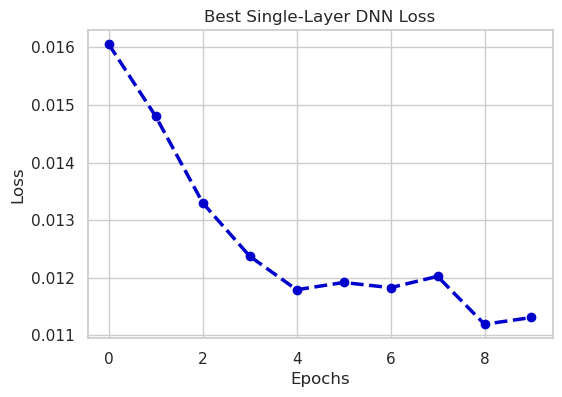

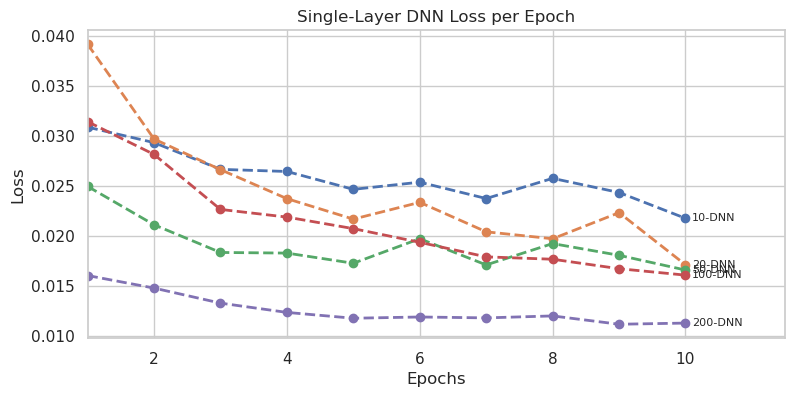

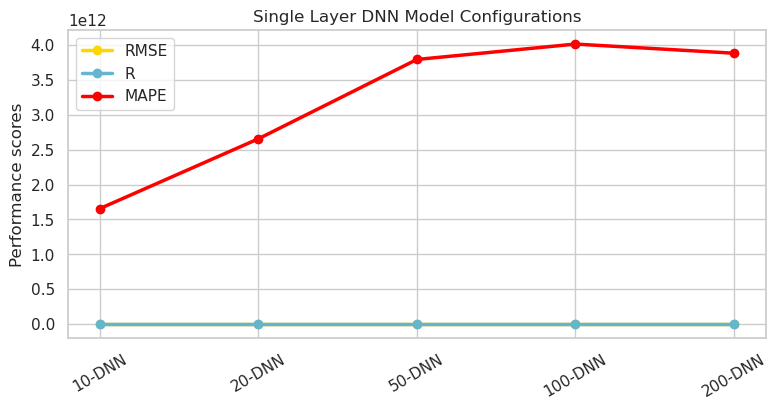

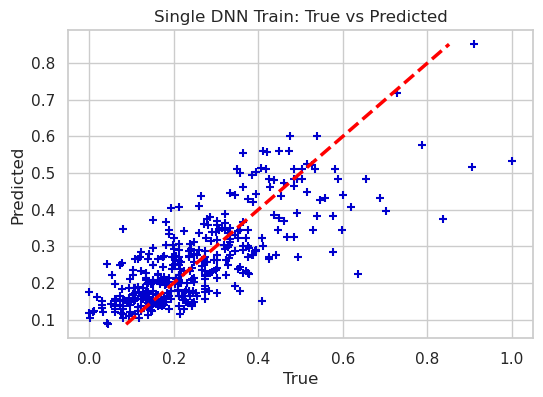

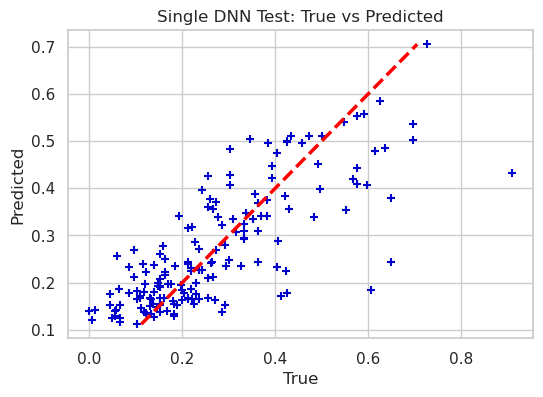

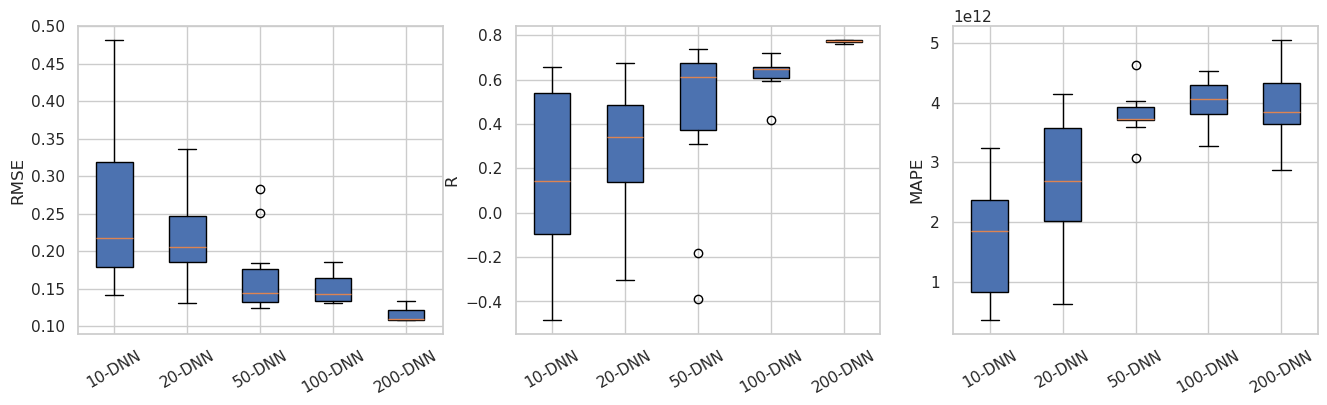

In [5]:
labels = ['10-DNN', '20-DNN', '50-DNN', '100-DNN', '200-DNN']

def plot_loss(loss, fig_name):
    fig = plt.figure(figsize=(6, 4))
    plt.plot(loss, '--o', linewidth=2.5, color='mediumblue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Best Single-Layer DNN Loss')
    fig.savefig(fig_name, dpi=600, bbox_inches='tight')
    plt.show()

def plot_all_losses(loss_files, fig_name):
    fig = plt.figure(figsize=(9, 4))
    for label, file_name in zip(labels, loss_files):
        loss = pd.read_csv(file_name).iloc[:, 1]
        x = range(1, len(loss) + 1)
        plt.plot(x, loss, '--o', linewidth=2, label=label)
        plt.text(len(loss) + 0.1, loss.iloc[-1], label, fontsize=8, va='center')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Single-Layer DNN Loss per Epoch')
    plt.xlim(1, max(len(pd.read_csv(f).iloc[:, 1]) for f in loss_files) + 1.5)
    fig.savefig(fig_name, dpi=600, bbox_inches='tight')
    plt.show()

def plot_avg_scores(avg_scores, fig_name):
    fig = plt.figure(figsize=(9, 4))
    plt.plot(labels, avg_scores['rmse'], '-o', linewidth=2.5, color='gold')
    plt.plot(labels, avg_scores['R'], '-o', linewidth=2.5, color='c')
    plt.plot(labels, avg_scores['mape'], '-o', linewidth=2.5, color='red')
    plt.ylabel('Performance scores')
    plt.title('Single Layer DNN Model Configurations')
    plt.xticks(rotation=30)
    plt.legend(['RMSE', 'R', 'MAPE'], loc='best')
    fig.savefig(fig_name, dpi=600, bbox_inches='tight')
    plt.show()

def plot_true_vs_pred(y_true, y_pred, title, fig_name):
    fig = plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, marker='+', color='mediumblue')
    line = np.linspace(max(min(y_true), min(y_pred)), min(max(y_true), max(y_pred)))
    plt.plot(line, line, color='red', linestyle='dashed', linewidth=2.5)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title(title)
    fig.savefig(fig_name, dpi=600, bbox_inches='tight')
    plt.show()

def plot_boxplots(rmse, R, mape, fig_name):
    fig = plt.figure(figsize=(16, 4))
    plt.subplot(131); plt.boxplot(rmse.T, patch_artist=True); plt.xticks(range(1, 6), labels, rotation=30); plt.ylabel('RMSE')
    plt.subplot(132); plt.boxplot(R.T, patch_artist=True); plt.xticks(range(1, 6), labels, rotation=30); plt.ylabel('R')
    plt.subplot(133); plt.boxplot(mape.T, patch_artist=True); plt.xticks(range(1, 6), labels, rotation=30); plt.ylabel('MAPE')
    fig.savefig(fig_name, dpi=600, bbox_inches='tight')
    plt.show()

loss_files = [output_dir_path + f'best-DNN_Regressor-{cfg}-loss.csv' for cfg in ['[10]', '[20]', '[50]', '[100]', '[200]']]
best_loss = pd.read_csv(output_dir_path + 'best_DNN_Regressor_model_loss.csv').iloc[:, 1]
best_train_pred = pd.read_csv(output_dir_path + 'best_DNN_Regressor_model_train_predictions.csv').iloc[:, 1]
best_test_pred = pd.read_csv(output_dir_path + 'best_DNN_Regressor_model_test_predictions.csv').iloc[:, 1]
avg_scores = pd.read_csv(output_dir_path + 'multiple_DNN_Regressor_models_average_scores.csv')
all_rmse = pd.read_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_rmse.csv').iloc[:, 1:].to_numpy()
all_R = pd.read_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_R.csv').iloc[:, 1:].to_numpy()
all_mape = pd.read_csv(output_dir_path + 'multiple_DNN_Regressor_models_all_mape.csv').iloc[:, 1:].to_numpy()
y_train_saved = pd.read_csv(output_dir_path + 'y_train.csv').iloc[:, 1]
y_test_saved = pd.read_csv(output_dir_path + 'y_test.csv').iloc[:, 1]

plot_loss(best_loss, output_dir_path + 'single_layer_best_loss_plot.png')
plot_all_losses(loss_files, output_dir_path + 'single_layer_loss_per_epoch_plot.pdf')
plot_avg_scores(avg_scores, output_dir_path + 'single_layer_avg_scores_plot.pdf')
plot_true_vs_pred(y_train_saved, best_train_pred, 'Single DNN Train: True vs Predicted', output_dir_path + 'single_layer_true_vs_prediction_train.pdf')
plot_true_vs_pred(y_test_saved, best_test_pred, 'Single DNN Test: True vs Predicted', output_dir_path + 'single_layer_true_vs_prediction_test.png')
plot_boxplots(all_rmse, all_R, all_mape, output_dir_path + 'single_DNN_all_scores_boxplots.pdf')